# Неделя 4 — Эксперимент A/B/C

Задание: `docs/week4_experiment.md`

In [55]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier

from src.validation import evaluate, time_split

# Загрузка данных
dataset = pd.read_parquet('../data/processed/dataset.parquet')

# Признаки
NUM_COLS = [c for c in dataset.columns
            if c not in ['segment', 'product', 'region', 'client_id', 'snapshot_date', 'target']]

# Разбиение по времени (одно для всех подходов!)
train, val, test = time_split(
    dataset,
    ['2024-07', '2024-10'],
    ['2025-01'],
    ['2025-10']
)

print(f"Train: {train.shape}, Val: {val.shape}, Test: {test.shape}")
print(f"Числовых признаков: {len(NUM_COLS)}")

Train: (60191, 24), Val: (32703, 24), Test: (36123, 24)
Числовых признаков: 18


## Подход A — единая модель без сегмента/продукта

In [56]:
# Подход A: единая модель БЕЗ segment в признаках
CAT_COLS_A = ['product', 'region']  # segment убран!

X_train_A = train[NUM_COLS + CAT_COLS_A]
X_val_A = val[NUM_COLS + CAT_COLS_A]
X_test_A = test[NUM_COLS + CAT_COLS_A]
y_train = train['target']
y_val = val['target']
y_test = test['target']

model_A = CatBoostClassifier(
    iterations=1000,
    early_stopping_rounds=100,
    eval_metric='AUC',
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=False,
)

model_A.fit(
    X_train_A, y_train,
    cat_features=CAT_COLS_A,
    eval_set=(X_val_A, y_val),
    use_best_model=True
)

print(f"best_iteration: {model_A.best_iteration_}")

score_A = model_A.predict_proba(X_test_A)[:, 1]
m_A = evaluate(y_test, score_A, 'Подход A: без segment')

best_iteration: 155
--- Подход A: без segment ---
ROC-AUC: 0.8407
PR-AUC: 0.5250
Precision@10%: 0.5274
Lift@10%: 6.49x
Доля оттока: 0.0812


## Подход B — единая модель + сегмент/продукт как признаки

In [57]:
# Подход B: единая модель С segment как признак
CAT_COLS_B = ['segment', 'product', 'region']  # segment возвращаем

X_train_B = train[NUM_COLS + CAT_COLS_B]
X_val_B = val[NUM_COLS + CAT_COLS_B]
X_test_B = test[NUM_COLS + CAT_COLS_B]

model_B = CatBoostClassifier(
    iterations=1000,
    early_stopping_rounds=100,
    eval_metric='AUC',
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=False,
)

model_B.fit(
    X_train_B, y_train,
    cat_features=CAT_COLS_B,
    eval_set=(X_val_B, y_val),
    use_best_model=True
)

print(f"best_iteration: {model_B.best_iteration_}")

score_B = model_B.predict_proba(X_test_B)[:, 1]
m_B = evaluate(y_test, score_B, 'Подход B: с segment')

best_iteration: 135
--- Подход B: с segment ---
ROC-AUC: 0.8435
PR-AUC: 0.5322
Precision@10%: 0.5263
Lift@10%: 6.48x
Доля оттока: 0.0812


## Подход C — отдельная модель на каждый сегмент

In [58]:
# Подход C: отдельная модель на каждый сегмент
CAT_COLS_C = ['product', 'region']  # segment не нужен внутри сегмента

segments = train['segment'].unique()
print(f"Сегменты: {segments}")

models_C = {}
scores_C = {}

for seg in segments:
    # Фильтруем данные по сегменту
    train_seg = train[train['segment'] == seg]
    val_seg = val[val['segment'] == seg]
    test_seg = test[test['segment'] == seg]

    # Проверка: достаточно ли примеров оттока?
    n_churn_train = train_seg['target'].sum()
    n_churn_test = test_seg['target'].sum()

    if n_churn_train < 100:
        print(f"⚠️ WARNING: {seg} — только {n_churn_train} примеров оттока в train!")

    print(f"\n=== Сегмент: {seg} ===")
    print(f"Train: {len(train_seg)}, Churn: {n_churn_train} ({n_churn_train/len(train_seg)*100:.1f}%)")
    print(f"Test: {len(test_seg)}, Churn: {n_churn_test} ({n_churn_test/len(test_seg)*100:.1f}%)")

    # Обучаем модель на этом сегменте
    model_seg = CatBoostClassifier(
        iterations=1000,
        early_stopping_rounds=100,
        eval_metric='AUC',
        auto_class_weights='Balanced',
        random_seed=42,
        verbose=False,
    )

    model_seg.fit(
        train_seg[NUM_COLS + CAT_COLS_C], train_seg['target'],
        cat_features=CAT_COLS_C,
        eval_set=(val_seg[NUM_COLS + CAT_COLS_C], val_seg['target']),
        use_best_model=True
    )

    print(f"best_iteration: {model_seg.best_iteration_}")

    models_C[seg] = model_seg
    scores_C[seg] = model_seg.predict_proba(test_seg[NUM_COLS + CAT_COLS_C])[:, 1]

# Склеиваем прогнозы всех сегментов в один вектор
score_C = pd.Series(index=test.index, dtype=float)
for seg in segments:
    test_seg = test[test['segment'] == seg]
    score_C.loc[test_seg.index] = scores_C[seg]

m_C = evaluate(y_test, score_C.values, 'Подход C: отдельные модели')

Сегменты: ['крупный бизнес' 'средний бизнес' 'малый бизнес']

=== Сегмент: крупный бизнес ===
Train: 10887, Churn: 389 (3.6%)
Test: 6779, Churn: 414 (6.1%)
best_iteration: 15

=== Сегмент: средний бизнес ===
Train: 20565, Churn: 1051 (5.1%)
Test: 12267, Churn: 1000 (8.2%)
best_iteration: 181

=== Сегмент: малый бизнес ===
Train: 28739, Churn: 1747 (6.1%)
Test: 17077, Churn: 1520 (8.9%)
best_iteration: 148
--- Подход C: отдельные модели ---
ROC-AUC: 0.8302
PR-AUC: 0.5167
Precision@10%: 0.5274
Lift@10%: 6.49x
Доля оттока: 0.0812


## Сравнение: общее и по сегментам

In [59]:
# Общее сравнение
print("=== Общее сравнение ===")
comparison = pd.DataFrame([m_A, m_B, m_C]).set_index('label')
print(comparison[['roc_auc', 'pr_auc', 'precision_at_10', 'lift_at_10']].round(4))

# Сравнение по сегментам
print("\n=== Сравнение по сегментам ===")
results_by_segment = []

from sklearn.metrics import roc_auc_score

def lift_at_k(y, score, k=0.10):
    """Lift@k% внутри подвыборки."""
    n = max(1, int(len(score) * k))
    idx = np.argsort(-score)[:n]
    return float(np.asarray(y)[idx].mean() / (np.asarray(y).mean() + 1e-12))

for seg in segments:
    # Булева маска вместо индексации по меткам
    mask = test['segment'] == seg
    y_seg = y_test[mask].values

    score_A_seg = score_A[mask]
    score_B_seg = score_B[mask]
    score_C_seg = scores_C[seg]

    # AUC внутри сегмента
    auc_A = roc_auc_score(y_seg, score_A_seg)
    auc_B = roc_auc_score(y_seg, score_B_seg)
    auc_C = roc_auc_score(y_seg, score_C_seg)

    # Lift внутри сегмента
    lift_A = lift_at_k(y_seg, score_A_seg)
    lift_B = lift_at_k(y_seg, score_B_seg)
    lift_C = lift_at_k(y_seg, score_C_seg)

    print(f"\n{seg}:")
    print(f"  A: AUC={auc_A:.4f}, Lift={lift_A:.2f}x")
    print(f"  B: AUC={auc_B:.4f}, Lift={lift_B:.2f}x")
    print(f"  C: AUC={auc_C:.4f}, Lift={lift_C:.2f}x")

    results_by_segment.append({
        'segment': seg,
        'A_AUC': auc_A, 'A_Lift': lift_A,
        'B_AUC': auc_B, 'B_Lift': lift_B,
        'C_AUC': auc_C, 'C_Lift': lift_C,
    })

df_segments = pd.DataFrame(results_by_segment).set_index('segment')
print("\n=== Итоговая таблица по сегментам ===")
print(df_segments.round(4))

=== Общее сравнение ===
                            roc_auc  pr_auc  precision_at_10  lift_at_10
label                                                                   
Подход A: без segment        0.8407  0.5250           0.5274      6.4934
Подход B: с segment          0.8435  0.5322           0.5263      6.4797
Подход C: отдельные модели   0.8302  0.5167           0.5274      6.4934

=== Сравнение по сегментам ===

крупный бизнес:
  A: AUC=0.8365, Lift=6.77x
  B: AUC=0.8400, Lift=6.72x
  C: AUC=0.8262, Lift=6.70x

средний бизнес:
  A: AUC=0.8438, Lift=6.61x
  B: AUC=0.8496, Lift=6.67x
  C: AUC=0.8498, Lift=6.81x

малый бизнес:
  A: AUC=0.8262, Lift=6.23x
  B: AUC=0.8271, Lift=6.21x
  C: AUC=0.8332, Lift=6.21x

=== Итоговая таблица по сегментам ===
                 A_AUC  A_Lift   B_AUC  B_Lift   C_AUC  C_Lift
segment                                                       
крупный бизнес  0.8365  6.7723  0.8400  6.7239  0.8262  6.6997
средний бизнес  0.8438  6.6138  0.8496  6.6738  0.

## Bootstrap-проверка значимости различий

In [60]:
from src.validation import bootstrap_auc_diff

# Сравниваем B vs A (главный вопрос: помогает ли segment?)
print("=== B vs A ===")
result_ba = bootstrap_auc_diff(y_test, score_B, score_A)

# Сравниваем B vs C
print("\n=== B vs C ===")
result_bc = bootstrap_auc_diff(y_test, score_B, score_C.values)

# Сравниваем A vs C
print("\n=== A vs C ===")
result_ac = bootstrap_auc_diff(y_test, score_A, score_C.values)

=== B vs A ===
Подход 1 лучше в 96% выборок; средняя разница AUC = +0.0028

=== B vs C ===
Подход 1 лучше в 100% выборок; средняя разница AUC = +0.0135

=== A vs C ===
Подход 1 лучше в 100% выборок; средняя разница AUC = +0.0107


## Feature importance + SHAP

=== Топ-15 признаков (CatBoost importance) ===
                 feature  importance
    revenue_last_to_mean   33.956410
revenue_declining_months   12.338251
          revenue_min_6m    6.521051
           revenue_trend    6.039714
      revenue_volatility    4.930677
         traffic_mean_6m    3.526090
         tickets_mean_6m    3.474904
           n_sim_mean_6m    3.294371
              n_sim_last    3.170256
            traffic_last    2.903314
           tenure_months    2.737587
               debt_last    2.548771
         revenue_mean_6m    2.542650
                 segment    2.541614
            debt_mean_6m    1.887484


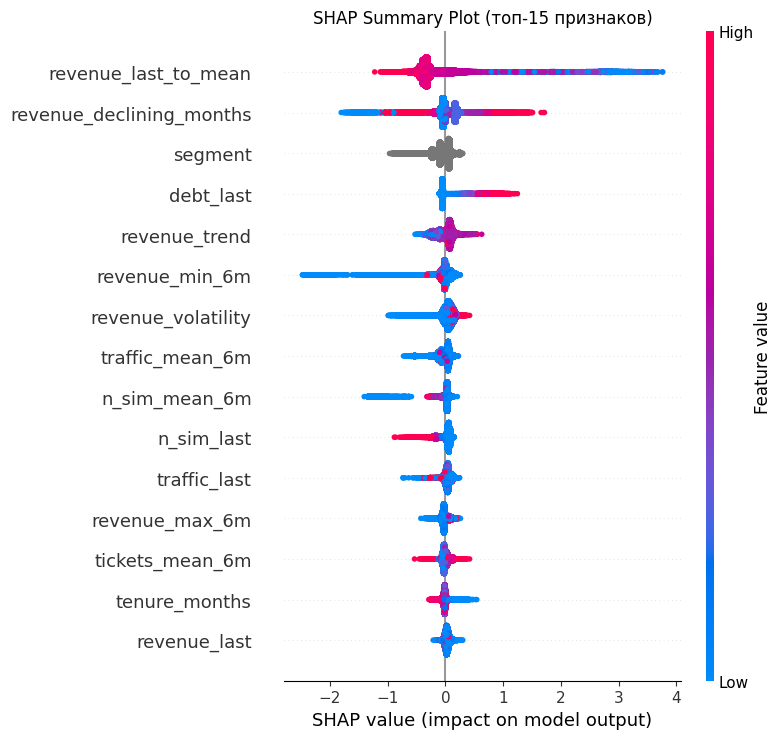

In [61]:
import shap
import matplotlib.pyplot as plt

# Feature importance от CatBoost (встроенный метод)
feature_importance = model_B.get_feature_importance()
feature_names = NUM_COLS + CAT_COLS_B

df_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("=== Топ-15 признаков (CatBoost importance) ===")
print(df_importance.head(15).to_string(index=False))

# SHAP summary plot
explainer = shap.TreeExplainer(model_B)
shap_values = explainer.shap_values(X_test_B)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_B, max_display=15, show=False)
plt.title('SHAP Summary Plot (топ-15 признаков)')
plt.tight_layout()
plt.show()

=== Клиент 1: УШЁЛ, модель дала высокий риск ===
segment                     средний бизнес
revenue_last_to_mean              0.557473
revenue_declining_months                 3
debt_last                          1869.77
tickets_mean_6m                   0.166667
Name: 24225, dtype: object
score: 0.992


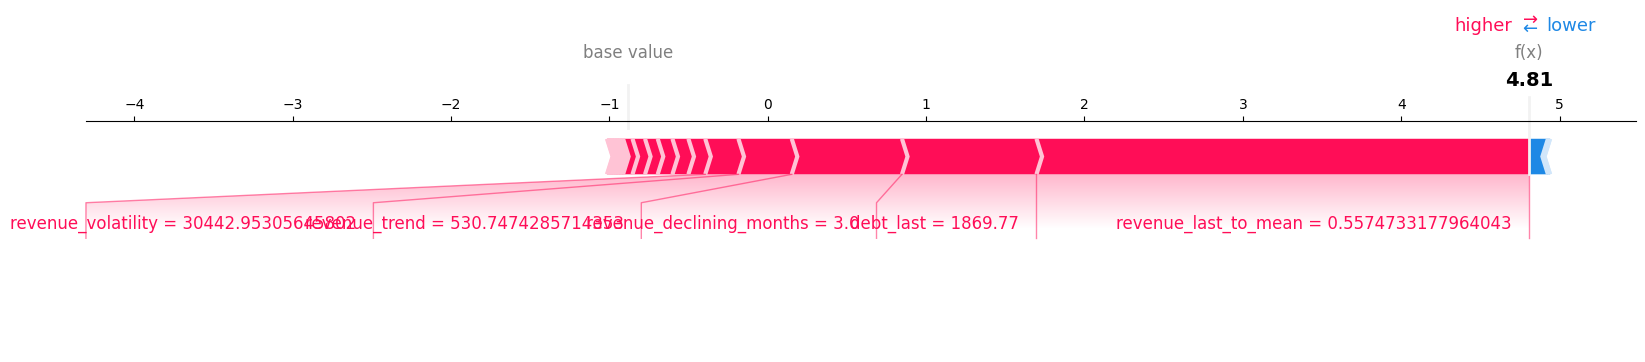


=== Клиент 2: ОСТАЛСЯ, модель дала низкий риск ===
segment                     малый бизнес
revenue_last_to_mean            1.618546
revenue_declining_months               0
debt_last                            0.0
tickets_mean_6m                 0.833333
Name: 10488, dtype: object
score: 0.000


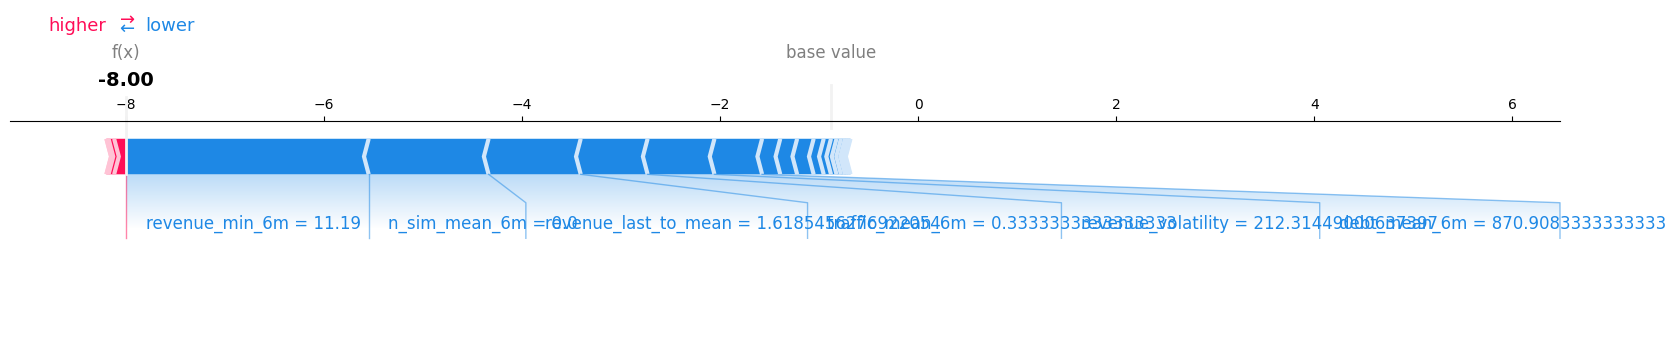

In [62]:
# Разбор двух конкретных клиентов
X_test_B_r = X_test_B.reset_index(drop=True)
y_arr = y_test.reset_index(drop=True).values

# Ушедший клиент, которого модель поймала с высокой уверенностью
churned_idx = np.where(y_arr == 1)[0]
pos_churned = int(churned_idx[np.argmax(score_B[churned_idx])])

# Активный клиент с минимальным риском
active_idx = np.where(y_arr == 0)[0]
pos_active = int(active_idx[np.argmin(score_B[active_idx])])

print("=== Клиент 1: УШЁЛ, модель дала высокий риск ===")
print(X_test_B_r.iloc[pos_churned][['segment', 'revenue_last_to_mean',
      'revenue_declining_months', 'debt_last', 'tickets_mean_6m']])
print(f"score: {score_B[pos_churned]:.3f}")

shap.force_plot(explainer.expected_value, shap_values[pos_churned],
                X_test_B_r.iloc[pos_churned], matplotlib=True)
plt.show()

print("\n=== Клиент 2: ОСТАЛСЯ, модель дала низкий риск ===")
print(X_test_B_r.iloc[pos_active][['segment', 'revenue_last_to_mean',
      'revenue_declining_months', 'debt_last', 'tickets_mean_6m']])
print(f"score: {score_B[pos_active]:.3f}")

shap.force_plot(explainer.expected_value, shap_values[pos_active],
                X_test_B_r.iloc[pos_active], matplotlib=True)
plt.show()